# TF (Term Frequency)

In [2]:
# 코퍼스를 토큰화
# 정제 . (마침표) 제거
text = "John likes to watch movies. Mary likes movies too.\
 Mary also likes to watch football games."
words = text.replace('.', '').split()
words

['John',
 'likes',
 'to',
 'watch',
 'movies',
 'Mary',
 'likes',
 'movies',
 'too',
 'Mary',
 'also',
 'likes',
 'to',
 'watch',
 'football',
 'games']

In [3]:
import numpy as np
word_count = np.unique(words, return_counts=True)
word_count

(array(['John', 'Mary', 'also', 'football', 'games', 'likes', 'movies',
        'to', 'too', 'watch'], dtype='<U8'),
 array([1, 2, 1, 1, 1, 3, 2, 2, 1, 2]))

In [4]:
#딕셔너리 TF 생성
word_to_cnt = {}
for word, cnt in zip(*word_count):
  word_to_cnt[word] = cnt
  
word_to_cnt

{'John': 1,
 'Mary': 2,
 'also': 1,
 'football': 1,
 'games': 1,
 'likes': 3,
 'movies': 2,
 'to': 2,
 'too': 1,
 'watch': 2}

In [5]:
word_to_cnt['movies']

2

In [6]:
corpus = [
    "John likes to watch movies. Mary likes movies too.",
    "Mary also likes to watch football games."
]

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
vector = CountVectorizer()
dtm_array = vector.fit_transform(corpus).toarray()
dtm_array

array([[0, 0, 0, 1, 2, 1, 2, 1, 1, 1],
       [1, 1, 1, 0, 1, 1, 0, 1, 0, 1]])

In [8]:
tf_dic = vector.vocabulary_
print(vector.vocabulary_)

{'john': 3, 'likes': 4, 'to': 7, 'watch': 9, 'movies': 6, 'mary': 5, 'too': 8, 'also': 0, 'football': 1, 'games': 2}


In [9]:
import pandas as pd
tf_dic_sorted = dict(sorted(tf_dic.items(), key=lambda item: item[1]))
#tf_dic_sorted
df = pd.DataFrame(dtm_array, columns=tf_dic_sorted.keys())
df

,also,football,games,john,likes,mary,movies,to,too,watch
0,0,0,0,1,2,1,2,1,1,1
1,1,1,1,0,1,1,0,1,0,1


# TF IDF Vectorizer

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vec = TfidfVectorizer()
tfidf_array = tfidf_vec.fit_transform(corpus).toarray()
#tfidf_array

In [11]:
tfidf_dic = tfidf_vec.vocabulary_
#tfidf_dic
tfidf_dic_sorted = dict(sorted(tfidf_dic.items(), key=lambda item: item[1]))
tfidf_dtm = pd.DataFrame(tfidf_array, columns=tfidf_dic_sorted.keys())
tfidf_dtm

,also,football,games,john,likes,mary,movies,to,too,watch
0,0.000000,0.000000,0.000000,0.323699,0.460629,0.230315,0.647398,0.230315,0.323699,0.230315
1,0.446101,0.446101,0.446101,0.000000,0.317404,0.317404,0.000000,0.317404,0.000000,0.317404


# Word2Vec - gensim Library

In [12]:
!pip install --upgrade gensim

In [13]:
!pip install "scipy<1.11"

In [14]:
from gensim.models import Word2Vec
corpus = [
    "John likes to watch movies. Mary likes movies too.",
    "Mary also likes to watch football games."
]
word_list = []

In [15]:
for word in corpus:
  word_list.append(word.replace('.','').split())
  
word_list

[['John', 'likes', 'to', 'watch', 'movies', 'Mary', 'likes', 'movies', 'too'],
 ['Mary', 'also', 'likes', 'to', 'watch', 'football', 'games']]

In [16]:
model = Word2Vec(word_list, sg=0, vector_size=100, window=3, min_count=1)
model.wv.most_similar('likes', 'movies')

[('John', 0.17164471745491028),
 ('also', 0.06594578176736832),
 ('Mary', 0.008838453330099583),
 ('watch', -0.06765829026699066),
 ('games', -0.08544928580522537),
 ('football', -0.08948154747486115),
 ('too', -0.11860241740942001),
 ('to', -0.13643866777420044)]

In [17]:
model = Word2Vec(word_list, sg=1, vector_size=100, window=3, min_count=1)
model.wv.most_similar('likes', 'movies')

[('John', 0.17164471745491028),
 ('also', 0.06594578176736832),
 ('Mary', 0.008853347972035408),
 ('watch', -0.06765829026699066),
 ('games', -0.08544928580522537),
 ('football', -0.08948154747486115),
 ('too', -0.11860241740942001),
 ('to', -0.13643862307071686)]

In [18]:
model = Word2Vec(word_list, sg=1, vector_size=100, window=3, min_count=1)
model.wv.most_similar('games')

[('to', 0.13887979090213776),
 ('watch', 0.13149002194404602),
 ('movies', 0.06408978253602982),
 ('too', 0.06059185042977333),
 ('football', 0.019152285531163216),
 ('Mary', 0.009383062832057476),
 ('also', -0.05774582177400589),
 ('likes', -0.05987628549337387),
 ('John', -0.10513809323310852)]

# # 전체 단어 임베딩 시각화 (PCA/t-SNE)

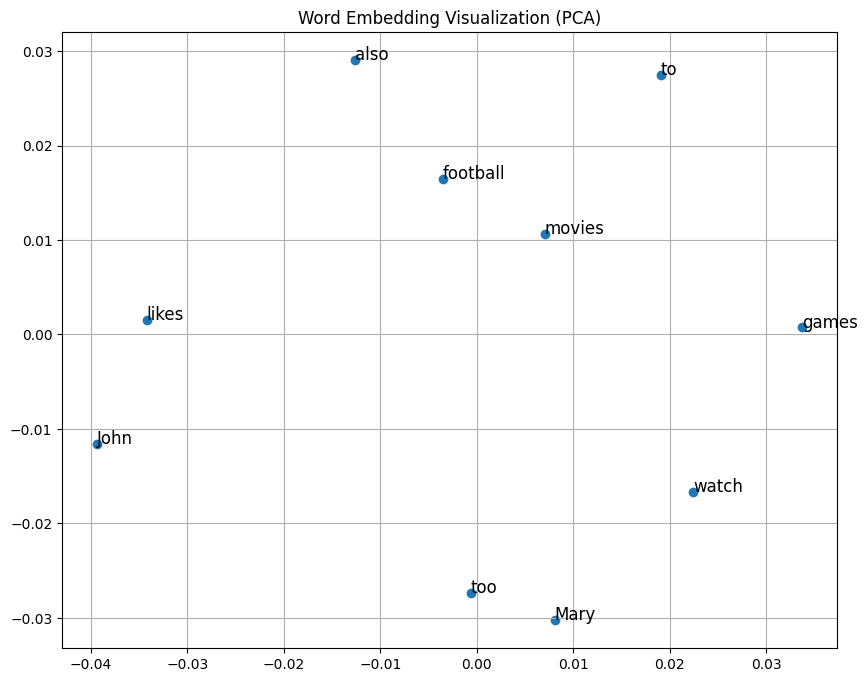

In [20]:
# 전체 단어 임베딩 시각화 (PCA/t-SNE)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_embeddings(model):
    # 단어와 벡터 추출
    words = list(model.wv.index_to_key)
    vectors = model.wv[words]

    # 100차원 -> 2차원 압축
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    # 시각화
    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1])

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)

    plt.title("Word Embedding Visualization (PCA)")
    plt.grid(True)
    plt.show()

visualize_embeddings(model)


# 코퍼스 추가

In [21]:
# 기존 코퍼스
corpus = [
    "John likes to watch movies. Mary likes movies too.",
    "Mary also likes to watch football games."
]

# 추가 코퍼스
new_corpus = [
    "John and Mary are good friends.",
    "They often go to the cinema together.",
    "Football is a popular sport in many countries.",
    "Mary enjoys watching drama and action movies.",
    "John plays football every weekend.",
    "They like to eat popcorn while watching movies.",
    "The football game was very exciting last night.",
    "Mary and John watched a new movie yesterday."
]

# 기존 + 추가 코퍼스 합치기
corpus = corpus + new_corpus
print(f"전체 문장 수: {len(corpus)}")

# 코퍼스 토큰화 (마침표 제거 후 단어 분리)
word_list = []
for sentence in corpus:
    word_list.append(sentence.replace('.', '').split())

word_list


전체 문장 수: 10


[['John', 'likes', 'to', 'watch', 'movies', 'Mary', 'likes', 'movies', 'too'],
 ['Mary', 'also', 'likes', 'to', 'watch', 'football', 'games'],
 ['John', 'and', 'Mary', 'are', 'good', 'friends'],
 ['They', 'often', 'go', 'to', 'the', 'cinema', 'together'],
 ['Football', 'is', 'a', 'popular', 'sport', 'in', 'many', 'countries'],
 ['Mary', 'enjoys', 'watching', 'drama', 'and', 'action', 'movies'],
 ['John', 'plays', 'football', 'every', 'weekend'],
 ['They', 'like', 'to', 'eat', 'popcorn', 'while', 'watching', 'movies'],
 ['The', 'football', 'game', 'was', 'very', 'exciting', 'last', 'night'],
 ['Mary', 'and', 'John', 'watched', 'a', 'new', 'movie', 'yesterday']]

# 모델 재학습 / 전체 시각화

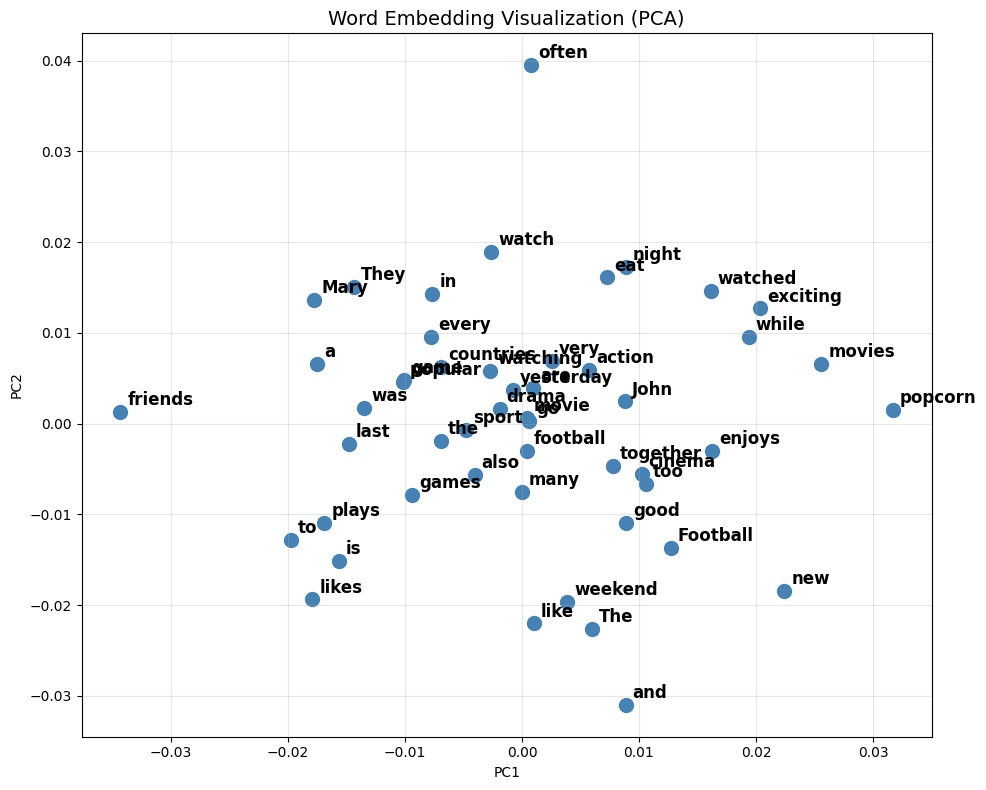

In [22]:
# Word2Vec 모델 재학습
from gensim.models import Word2Vec

model = Word2Vec(word_list, sg=1, vector_size=100, window=3, min_count=1)

# 전체 단어 임베딩 시각화 (PCA)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_embeddings(model):
    # 단어와 벡터 추출
    words = list(model.wv.index_to_key)
    vectors = model.wv[words]

    # 100차원 -> 2차원 압축
    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    # 시각화
    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1], c='steelblue', s=100)

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]),
                     fontsize=12, fontweight='bold',
                     xytext=(5, 5), textcoords='offset points')

    plt.title("Word Embedding Visualization (PCA)", fontsize=14)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_embeddings(model)
